###**"Restoration of Fog/Haze-Degraded Outdoor Images Using Dark Channel Prior and Guided Filtering"**

Step 1 done: CLEAN.jpg and HAZY.jpg created.
Step 2 done: Estimated atmospheric light (A): [0.8557843  0.9010784  0.91186273]
Step 3 done: Transmission map refined using manual guided filter.
Step 4 done: DEHAZED.jpg created.


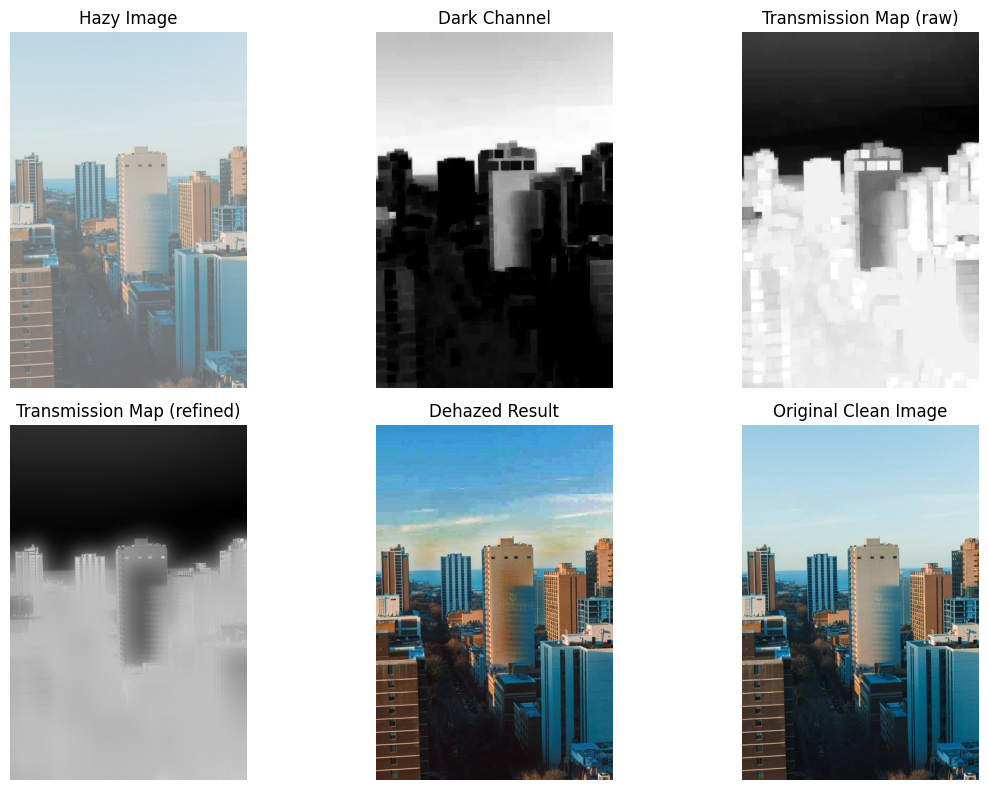


===== EVALUATION RESULTS =====
PSNR before dehazing (hazy vs clean):    12.71
PSNR after dehazing  (dehazed vs clean): 17.76
SSIM before dehazing (hazy vs clean):    0.766
SSIM after dehazing  (dehazed vs clean): 0.924


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# =================================================================
# PART 1: LOAD YOUR CLEAN PHOTO AND CREATE A SYNTHETIC HAZY VERSION
# =================================================================
img_bgr = cv2.imread("/content/photo1.jfif")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

A_true = np.array([0.9, 0.9, 0.9], dtype=np.float32)
t_true = 0.55

hazy = img * t_true + A_true * (1 - t_true)
hazy = np.clip(hazy, 0, 1)

cv2.imwrite("CLEAN.jpg", cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
cv2.imwrite("HAZY.jpg", cv2.cvtColor((hazy * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
print("Step 1 done: CLEAN.jpg and HAZY.jpg created.")


# =================================================================
# PART 2: DEHAZE THE HAZY IMAGE (DARK CHANNEL PRIOR ALGORITHM)
# =================================================================

# ---------------- STEP 1: DARK CHANNEL ----------------
min_channel = np.min(hazy, axis=2)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
dark_channel = cv2.erode(min_channel, kernel)

# ---------------- STEP 2: ATMOSPHERIC LIGHT ----------------
h, w = dark_channel.shape
num_pixels = h * w
num_top = int(num_pixels * 0.001) + 1

flat_dark = dark_channel.reshape(num_pixels)
flat_img = hazy.reshape(num_pixels, 3)

top_indices = np.argsort(flat_dark)[-num_top:]
brightest_pixels = flat_img[top_indices]

A_est = np.max(brightest_pixels, axis=0)
print("Step 2 done: Estimated atmospheric light (A):", A_est)

# ---------------- STEP 3: TRANSMISSION MAP ----------------
omega = 0.95
normalized_img = hazy / A_est
min_channel_norm = np.min(normalized_img, axis=2)
dark_channel_norm = cv2.erode(min_channel_norm, kernel)
transmission = 1 - omega * dark_channel_norm

# ---------------- STEP 4: SMOOTH THE TRANSMISSION MAP ----------------
gray_img = cv2.cvtColor((hazy * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
gray_img = gray_img.astype(np.float32) / 255.0

radius = 40
eps = 0.001
p = transmission.astype(np.float32)

mean_I = cv2.boxFilter(gray_img, cv2.CV_32F, (radius, radius))
mean_p = cv2.boxFilter(p, cv2.CV_32F, (radius, radius))
mean_Ip = cv2.boxFilter(gray_img * p, cv2.CV_32F, (radius, radius))
cov_Ip = mean_Ip - mean_I * mean_p

mean_II = cv2.boxFilter(gray_img * gray_img, cv2.CV_32F, (radius, radius))
var_I = mean_II - mean_I * mean_I

a_coef = cov_Ip / (var_I + eps)
b_coef = mean_p - a_coef * mean_I

mean_a = cv2.boxFilter(a_coef, cv2.CV_32F, (radius, radius))
mean_b = cv2.boxFilter(b_coef, cv2.CV_32F, (radius, radius))

refined_transmission = mean_a * gray_img + mean_b
print("Step 3 done: Transmission map refined using manual guided filter.")

# ---------------- STEP 5: RECOVER THE HAZE-FREE IMAGE ----------------
t0 = 0.1
t_clipped = np.maximum(refined_transmission, t0)
t_clipped = t_clipped[:, :, np.newaxis]

recovered = (hazy - A_est) / t_clipped + A_est
recovered = np.clip(recovered, 0, 1)

cv2.imwrite("DEHAZED.jpg", cv2.cvtColor((recovered * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
print("Step 4 done: DEHAZED.jpg created.")


# =================================================================
# PART 3: DISPLAY THE PIPELINE STAGES
# =================================================================
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(hazy)
plt.title("Hazy Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(dark_channel, cmap="gray")
plt.title("Dark Channel")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(transmission, cmap="gray")
plt.title("Transmission Map (raw)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(refined_transmission, cmap="gray")
plt.title("Transmission Map (refined)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(recovered)
plt.title("Dehazed Result")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(img)
plt.title("Original Clean Image")
plt.axis("off")

plt.tight_layout()
plt.savefig("output_comparison.png", dpi=150)
plt.show()


# =================================================================
# PART 4: EVALUATE RESULTS (PSNR AND SSIM)
# =================================================================
psnr_before = psnr(img, hazy, data_range=1.0)
psnr_after = psnr(img, recovered, data_range=1.0)

ssim_before = ssim(img, hazy, data_range=1.0, channel_axis=2)
ssim_after = ssim(img, recovered, data_range=1.0, channel_axis=2)

print("\n===== EVALUATION RESULTS =====")
print(f"PSNR before dehazing (hazy vs clean):    {psnr_before:.2f}")
print(f"PSNR after dehazing  (dehazed vs clean): {psnr_after:.2f}")
print(f"SSIM before dehazing (hazy vs clean):    {ssim_before:.3f}")
print(f"SSIM after dehazing  (dehazed vs clean): {ssim_after:.3f}")